In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from typing import Dict, List, Optional
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

In [3]:
def fin(df, radius, fpSize):
    fingerprints = []
    onbits_list = []
    fp_generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize)
    for i, mol in enumerate(df["ROMol"]):
        try:
            fp = fp_generator.GetFingerprint(mol)
            # 1になっているビットの位置を取得
            onbits = list(fp.GetOnBits())
            onbits_list.append(onbits)
            
            # NumPy配列も必要なら
            fp_np = fp_generator.GetFingerprintAsNumPy(mol)
            fingerprints.append(fp_np)

        except Exception as e:
            print(f"Error processing molecule {i}: {e}")
            continue
    return np.array(fingerprints), onbits_list


In [ ]:
def load_data(file_path: str) -> pd.DataFrame:
    """Load dataset from pickle file
    
    Args:
        file_path: Path to the pickle file containing the dataset
        
    Returns:
        DataFrame containing the loaded dataset
    """
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    return data

def add_vectors(fp_list: List[List[int]], model: Doc2Vec) -> List[np.ndarray]:
    """Combine document vectors based on fingerprints
    
    Args:
        fp_list: List of fingerprint lists, where each fingerprint is represented as a list of indices
        model: Trained Doc2Vec model containing document vectors
        
    Returns:
        List of compound vectors as numpy arrays
    """
    compound_vec = []
    for i in fp_list:
        fingerprint_vec = 0
        for j in i:
            fingerprint_vec += model.dv.vectors[j]
        compound_vec.append(fingerprint_vec)
    return compound_vec

def generate_umap_embedding(vectors: List[np.ndarray], n_neighbors: int, min_dist: float, n_components: int = 2) -> np.ndarray:
    """Generate UMAP embedding from input vectors
    
    Args:
        vectors: List of vectors to embed
        n_components: Number of dimensions in the embedding
        n_neighbors: Number of neighbors to consider during embedding
        min_dist: Minimum distance between points in the embedding
        
    Returns:
        NumPy array containing the embedded coordinates
    """
    umap_model = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors, 
        min_dist=min_dist,
        metric='cosine',
        random_state=0
    )
    return umap_model.fit_transform(vectors)


def plot_chemical_categories(df: pd.DataFrame, dim_df: pd.DataFrame, 
                            categories: List[str], categories_display: List[str], 
                            output_file: Optional[str] = None) -> None:
    """Create multi-panel plot for different chemical categories
    
    Args:
        df: DataFrame containing compound information and category labels
        dim_df: DataFrame containing the 2D embedding coordinates
        categories: List of category column names in df
        categories_display: List of category display names for plot titles
        output_file: Path where the output figure will be saved. If None, figure is not saved
        
    Returns:
        None
    """
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for idx, category in enumerate(categories):
        ax = axes[idx]
        
        # Create DataFrame with category labels and coordinates
        names_tb = pd.DataFrame(
            { "NAME": [i[0] for i in df["compounds"]],
             "category": [1 if i == category else 0 for i in df[category]]}
        )
        index_tb = pd.concat([names_tb, dim_df], axis=1)
        
        # Plot non-category points (blue)
        mask_0 = index_tb["category"] == 0
        ax.scatter(index_tb[mask_0]["x"], index_tb[mask_0]["y"], 
                  c='blue', s=9, alpha=0.6, label='non')
        
        # Plot category points (red)
        mask_1 = index_tb["category"] == 1
        ax.scatter(index_tb[mask_1]["x"], index_tb[mask_1]["y"], 
                  c='red', s=9, alpha=1, label=category)
        
        ax.set_title(categories_display[idx], fontsize=21, fontweight='bold')
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        # ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.tick_params(axis='both', which='major', labelsize=8)
    
    plt.tight_layout()
    
    # Save figure if output file is specified
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return None
    
def make_fp2vector(model_path: str, df: pd.DataFrame) -> np.ndarray:
    """Convert to compound vectors using FpDoc2Vec model
    
    Args:
        model_path: Path to the saved FpDoc2Vec model file
        df: DataFrame containing compound data with 'fp_3_4096' column
        
    Returns:
        NumPy array of compound vectors with shape (len(compound_vec), vector_size)
    """
    model = Doc2Vec.load(model_path)
    finger_list = list(df["fp_3_4096"])
    compound_vec = add_vectors(finger_list, model)
    vec = np.array(compound_vec)
    return vec

def make_name2vector(df, model_path):

    model = Doc2Vec.load(model_path)
    X_vec = np.array([model.dv.vectors[i] for i in range(len(df))])

    return X_vec

def make_descriptors(
    input_file: str, 
    train_df: pd.DataFrame, 
) -> Dict[str, Dict[str, float]]:

    # Load dataset
    with open(input_file, "rb") as f:
        df = pickle.load(f)
        
    # Split data into train and test sets
    train_df1 = df[df["inchikey"].isin(list(train_df["inchikey"]))]
    test_df1 = df.drop(train_df1.index)
    
    # Extract descriptor columns (from column 14 onward)
    train_desc = np.array(train_df1.iloc[:, 14:])
    test_desc = np.array(test_df1.iloc[:, 14:])

    return train_df1, test_df1, train_desc, test_desc

def main(input_path: str, vec: Dict[str, np.ndarray], output_path: str, n_neighbors: int, min_dist: float) -> None:
    """Process chemical data and generate UMAP visualization of chemical categories
    
    Args:
        input_path: Path to the input pickle file containing chemical dataset
        vec: Dictionary mapping compound IDs to their vector representations
        output_path: Path where the output visualization will be saved
        
    Returns:
        None
    """
    # Load dataset and model
    df = load_data(input_path)
    
    # Generate UMAP embedding
    umap_result = generate_umap_embedding(vec, n_neighbors, min_dist)
    dim_df = pd.DataFrame(umap_result, columns=["x", "y"])
    
    # Define categories and their display names
    categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin',
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 
        'insecticide'
    ]
    
    display_names = [
        '"antioxidant"', '"anti-inflammatory agent"', '"allergen"', '"dye"', 
        '"toxin"', '"flavouring agent"', '"agrochemical"', '"volatile oil"', 
        '"antibacterial agent"', '"insecticide"'
    ]
    
    # Create visualization
    plot_chemical_categories(df, dim_df, categories, display_names, output_path)
    
    return None


/opt/anaconda3/envs/FpDoc2Vec/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


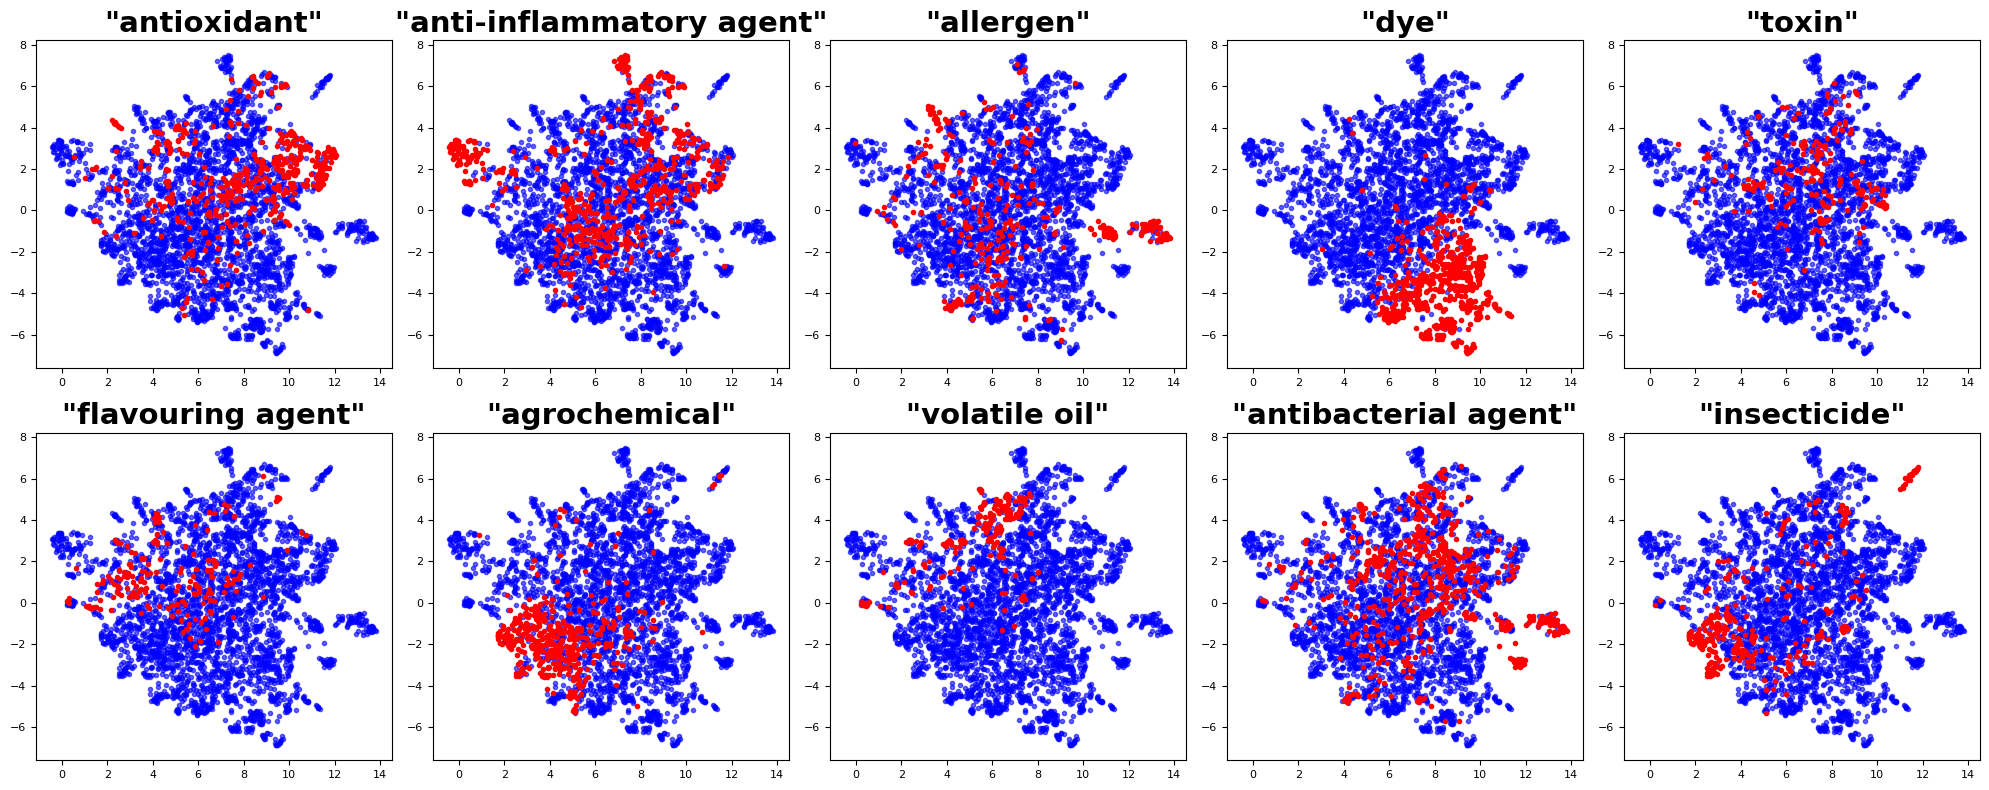

In [19]:
#FpDoc2vec visualization
input_path = "data/train_df2.pkl"
model_path = "train_df_doc2vec.model"
output_path = "fpdoc2vec_umap.png"
df = load_data(input_path)
vec = make_fp2vector(model_path, df)
main(input_path, vec, output_path, 30, 0.5)

/opt/anaconda3/envs/FpDoc2Vec/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


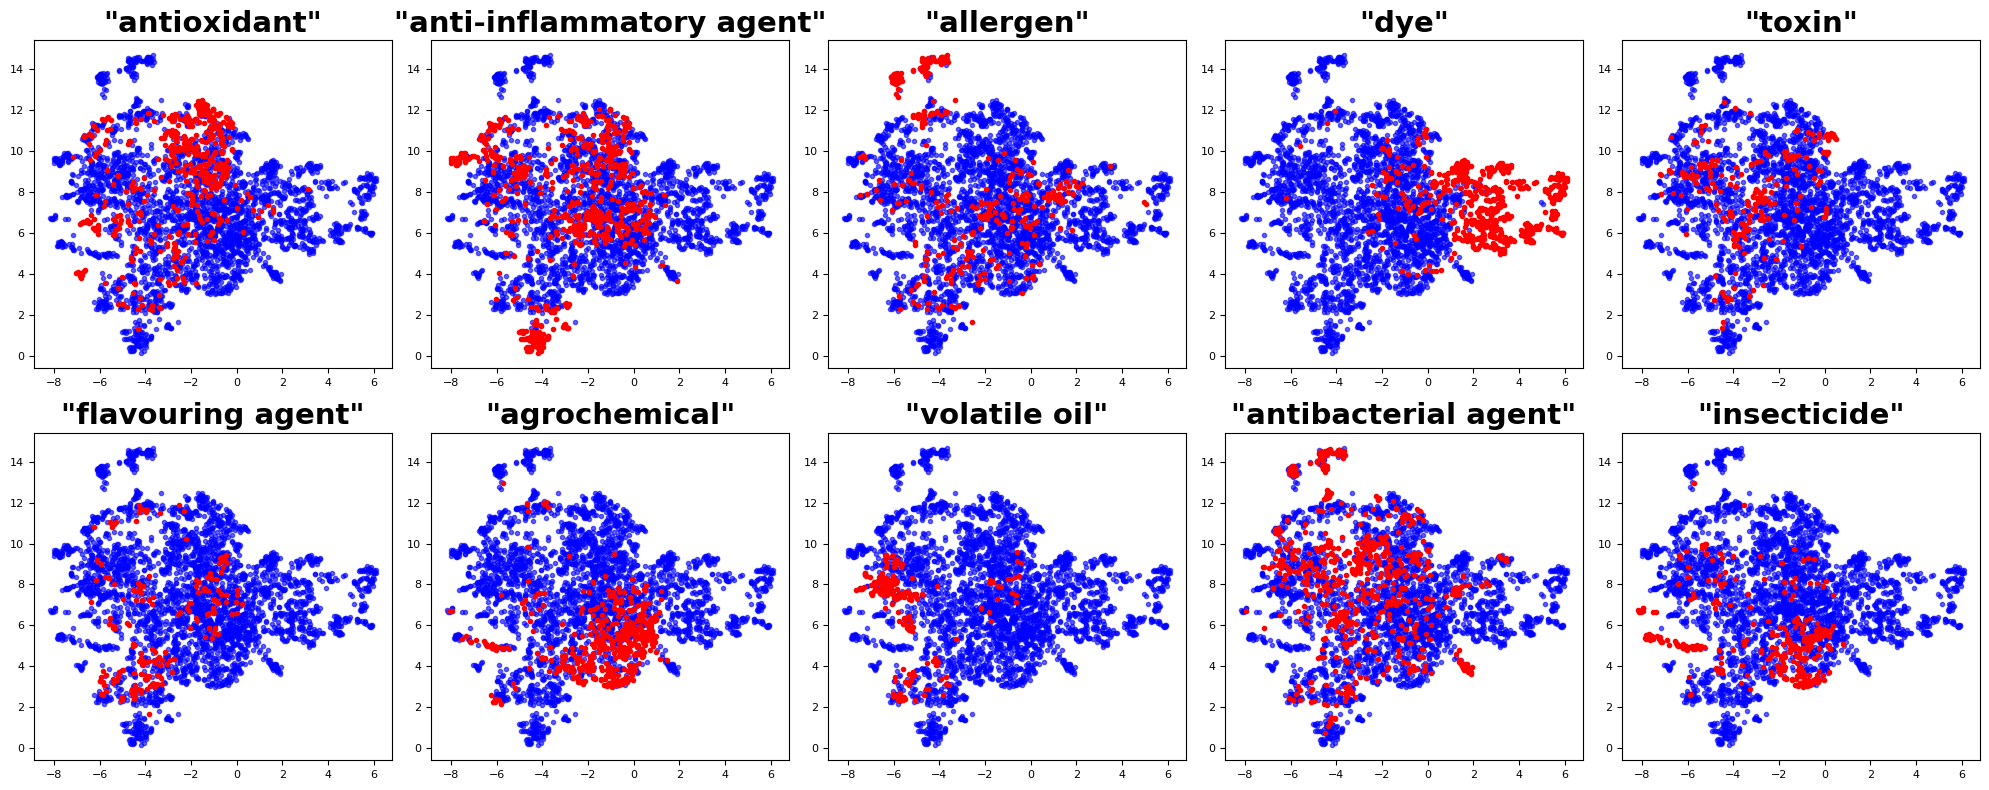

In [18]:
#ECFP visualization
input_path = "data/train_df2.pkl"
output_path = "ECFP_umap.png"
df = load_data(input_path)
ecfp, onbits_list = fin(df, radius=3, fpSize=4096)
main(input_path, ecfp, output_path, 30, 0.5)

/opt/anaconda3/envs/FpDoc2Vec/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


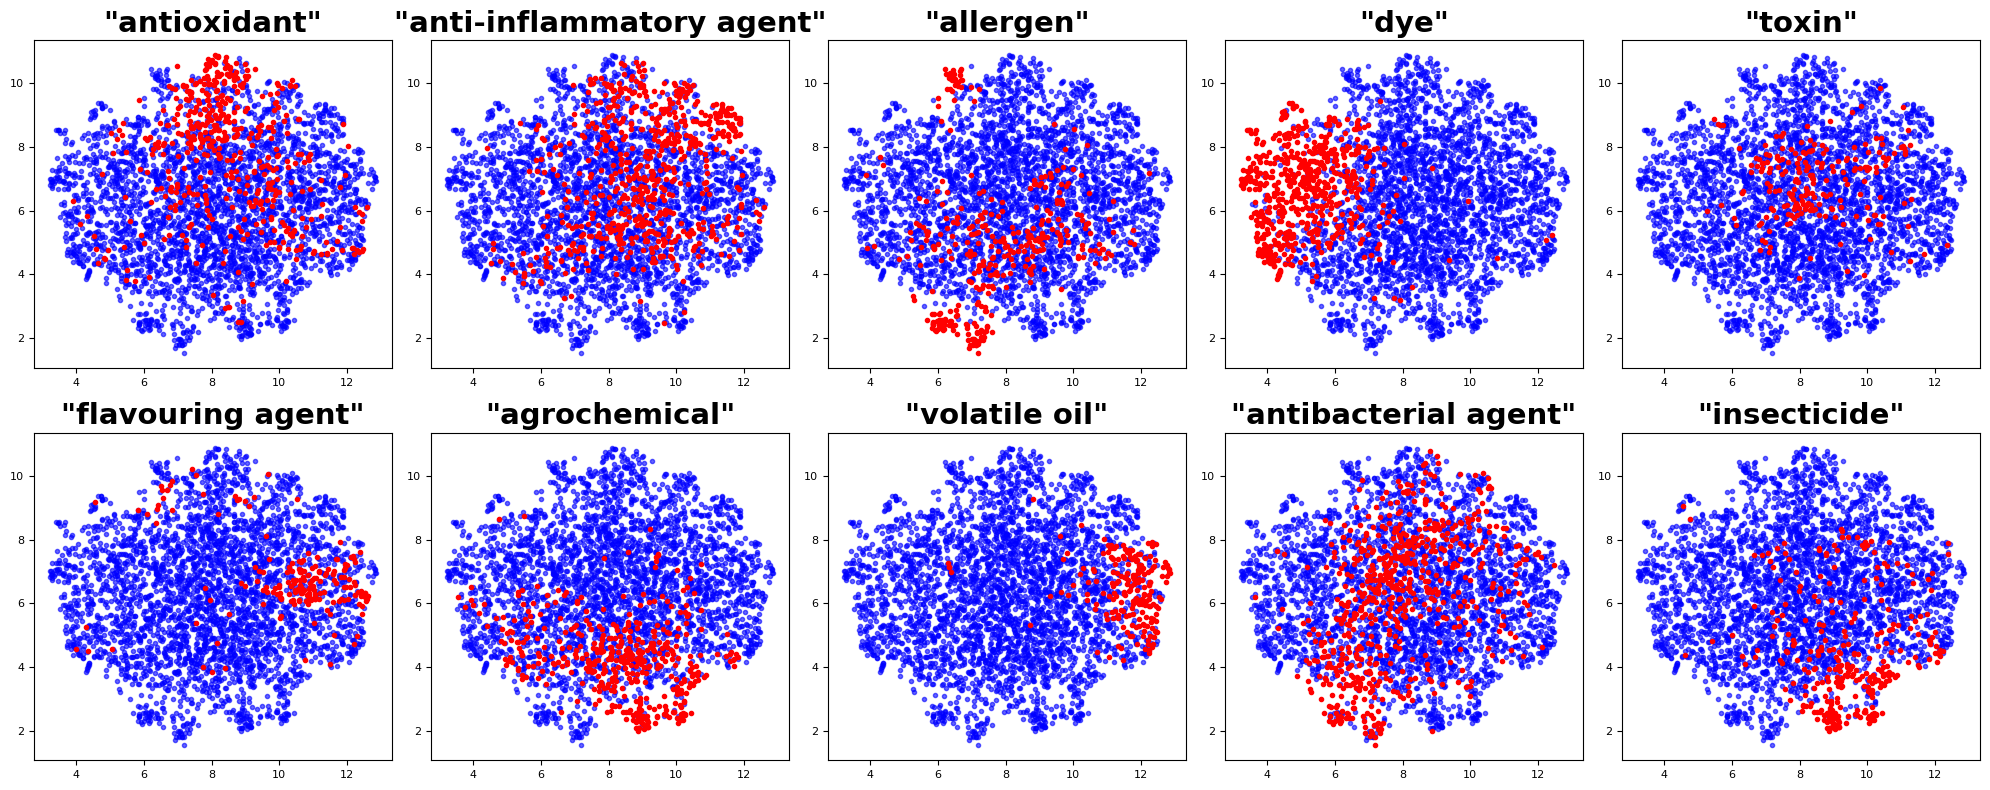

In [43]:
#NameDoc2vec visualization
input_path = "data/train_df2.pkl"
output_path = "NameDoc2vec_umap.png"
model_path = "train_df_namedoc2vec.model"
df = load_data(input_path)
vec = make_name2vector(df, model_path)
main(input_path, vec, output_path, 30, 0.5)

/opt/anaconda3/envs/FpDoc2Vec/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


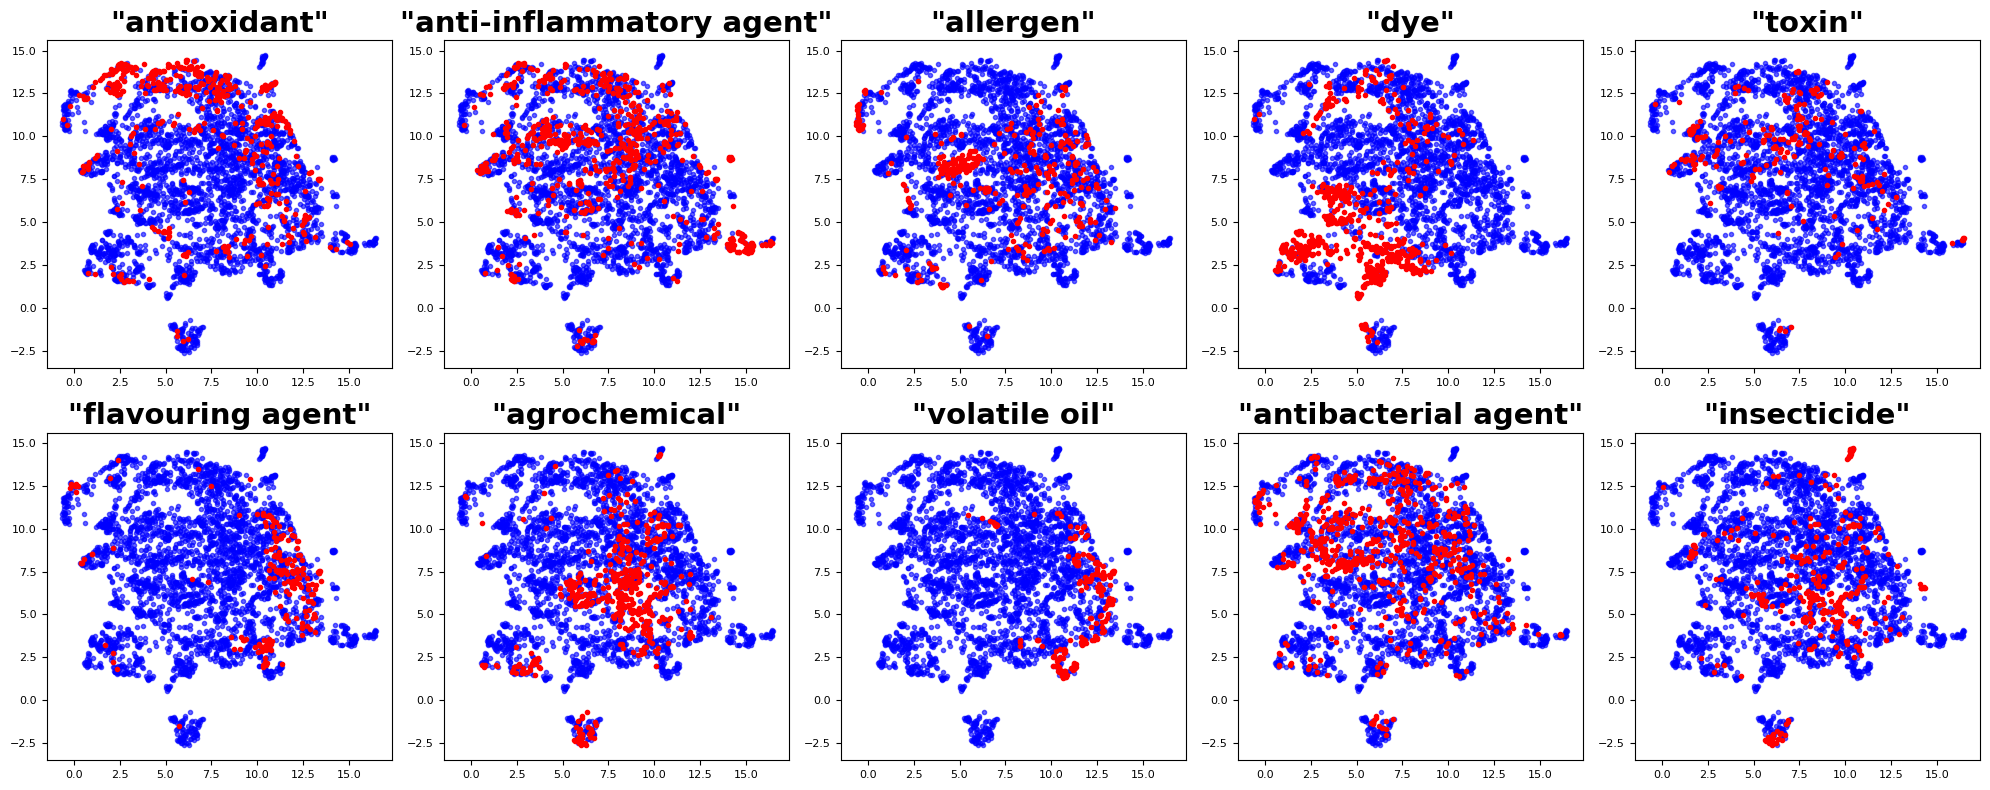

In [6]:
#descriptorsvisualization
input_path = "data/train_df2.pkl"
df = load_data(input_path)

input_descriptor_path = "data/10genre_32descriptor.pkl"
output_path = "descriptors_umap.png"
train_df, test_df ,X_train_vec, X_test_vec = make_descriptors(input_descriptor_path, df)
main(input_path, X_train_vec, output_path, 30, 0.5)

In [45]:
def plot_chemical_categories(df: pd.DataFrame, dim_df: pd.DataFrame, 
                            categories: List[str], categories_display: List[str], output_file):
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    axes = axes.flatten()
    
    for idx, category in enumerate(categories):
        ax = axes[idx]
        
        names_tb = pd.DataFrame(
            {"NAME": [i[0] for i in df["compounds"]], 
             "category": [1 if i == category else 0 for i in df[category]]}
        )
        index_tb = pd.concat([names_tb, dim_df], axis=1)
        
        mask_0 = index_tb["category"] == 0
        ax.scatter(index_tb[mask_0]["x"], index_tb[mask_0]["y"], 
                  c='blue', s=9, alpha=0.6, label='non')
        
        mask_1 = index_tb["category"] == 1
        ax.scatter(index_tb[mask_1]["x"], index_tb[mask_1]["y"], 
                  c='red', s=9, alpha=1, label=category)
        
        ax.set_title(categories_display[idx], fontsize=29, fontweight='bold')
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.tick_params(axis='both', which='major', labelsize=8)
    
    plt.tight_layout()
    
    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return None

def main(vec: Dict[str, np.ndarray], output_path, n_neighbors: int, min_dist: float) -> None:
    
    umap_result = generate_umap_embedding(vec,n_neighbors, min_dist)
    dim_df = pd.DataFrame(umap_result, columns=["x", "y"])
    
    categories = [
        'antioxidant', 'dye', 'toxin',
        'flavouring_agent', 'volatile_oil',  'insecticide'
    ]
    
    display_names = [
        '"antioxidant"', '"dye"', '"toxin"',
        '"flavouring agent"', '"volatile oil"', '"insecticide"'
    ]
    
    plot_chemical_categories(df, dim_df, categories, display_names, output_path)
    
    return None

/opt/anaconda3/envs/FpDoc2Vec/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


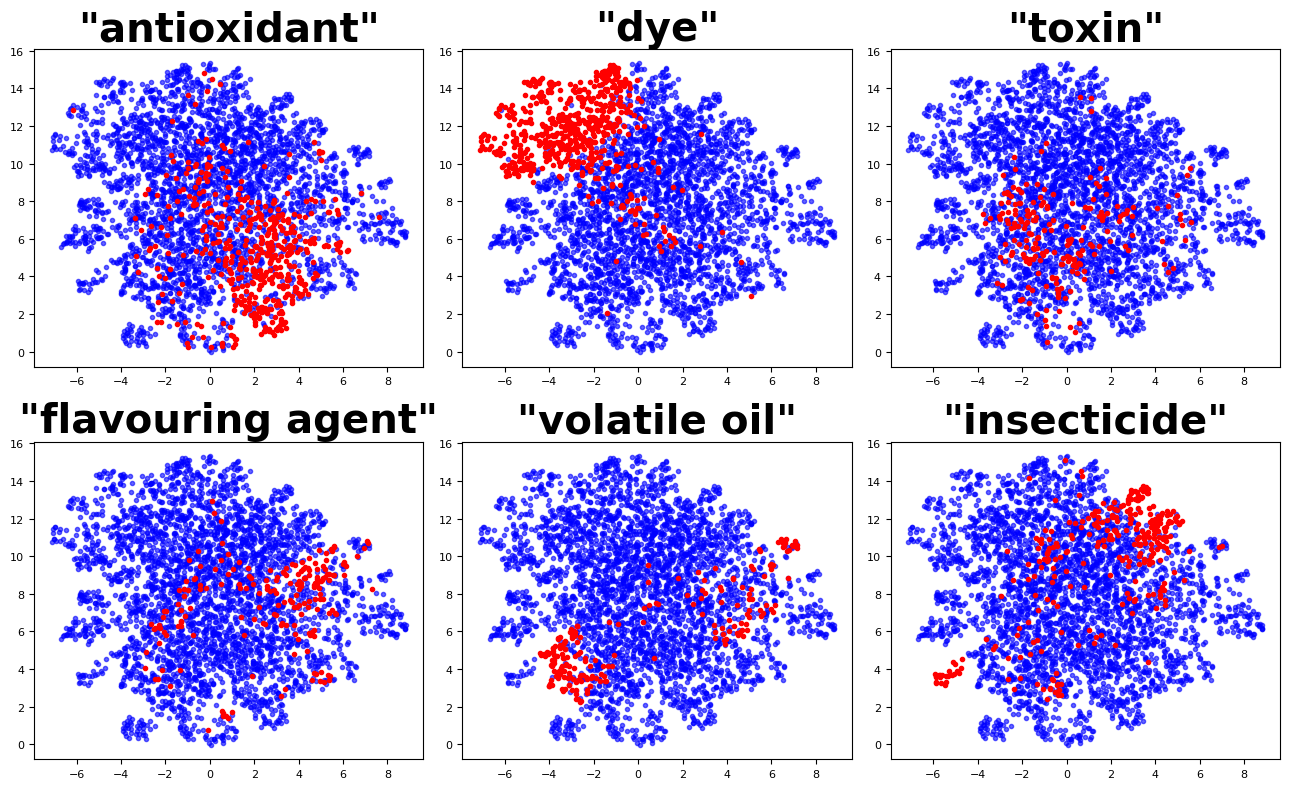

In [46]:
input_path = "data/train_df2.pkl"
df = load_data(input_path)
vec = make_fp2vector(model_path, df)
model_path = "train_df_doc2vec.model"
output_path = "fpdoc2vec_umap2.png"
main(vec, output_path, 50, 1)

/opt/anaconda3/envs/FpDoc2Vec/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


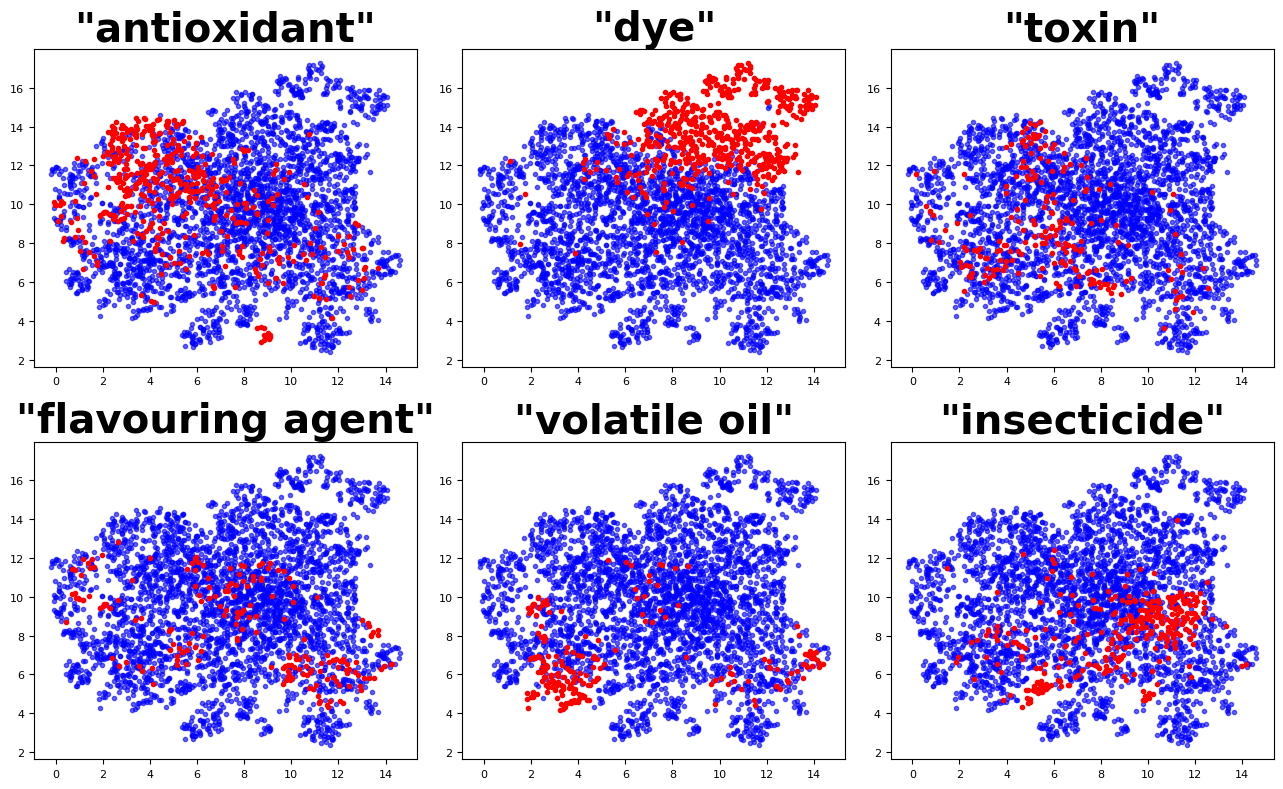

In [47]:
input_path = "data/train_df2.pkl"
df = load_data(input_path)
ecfp, onbits_list = fin(df, radius=3, fpSize=4096)
model_path = "train_df_doc2vec.model"
output_path = "ECFP_umap2.png"
main(ecfp, output_path, 50, 1)